In [31]:
import numpy as np
import matplotlib.pyplot as plt

# coastline: x-position as a function of y
n = 100
coast = np.random.rand(n) * 10  # rough "young" coastline

k = 0.1       # erosion coefficient
dt = 0.1      # time step
steps = 300   # number of iterations

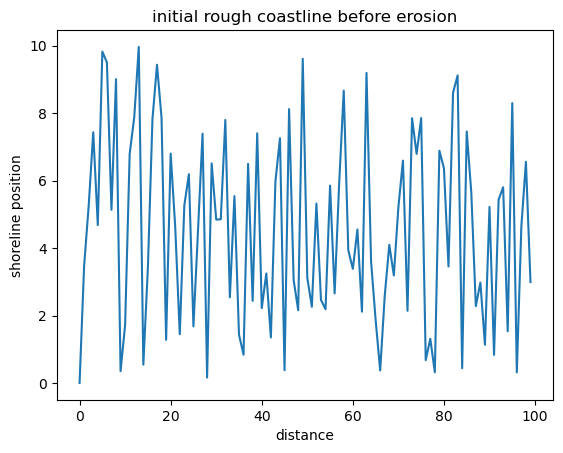

In [32]:
plt.plot(coast)
plt.title("initial rough coastline before erosion")
plt.xlabel("distance")
plt.ylabel("shoreline position")
plt.show()

In [33]:
wave_energy = 1 + 0.5*np.sin(np.linspace(0, 4*np.pi, n))


for t in range(steps):
    laplacian = np.roll(coast, -1) - 2*coast + np.roll(coast, 1)

    coast += k * wave_energy * laplacian * dt

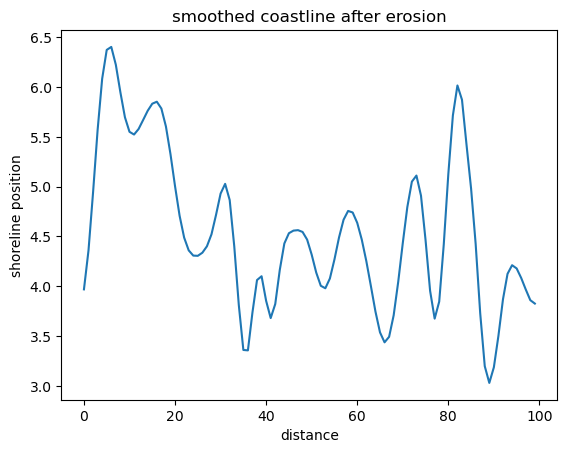

In [34]:
plt.plot(coast)
plt.title("smoothed coastline after erosion")
plt.xlabel("distance")
plt.ylabel("shoreline position")
plt.show()

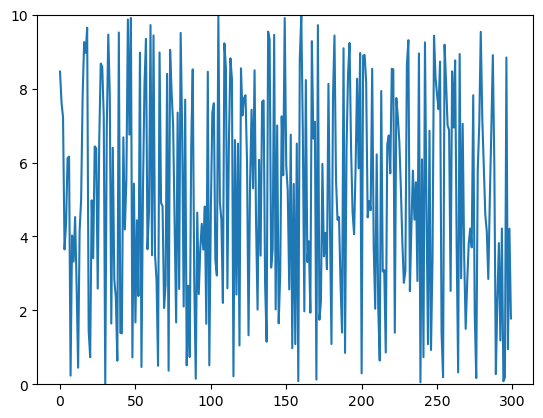

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

n = 300
coast = np.random.rand(n) * 10

k = 0.1
dt = 0.1
steps = 300

wave_energy = 1 + 0.5*np.sin(np.linspace(0, 4*np.pi, n))

fig, ax = plt.subplots()
line, = ax.plot(coast)
ax.set_ylim(0, 10)

def update(frame):
    global coast
    laplacian = np.roll(coast, -1) - 2*coast + np.roll(coast, 1)
    coast = coast + k * wave_energy * laplacian * dt
    
    line.set_ydata(coast)
    ax.set_title(f"Step {frame}")
    return line,

ani = FuncAnimation(fig, update, frames=steps, interval=50)
plt.show()

ani.save("coastline_erosion.gif", writer="pillow", fps=20)